In [1]:
import sys
from pathlib import Path

# >>>> CHANGE THIS if your path is a bit different <<<<
SRC_ROOT = Path("/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/src")

print("SRC_ROOT exists? ", SRC_ROOT.exists())
print("SRC_ROOT path    ", SRC_ROOT)

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print("Added to sys.path")


SRC_ROOT exists?  True
SRC_ROOT path     /Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/src
Added to sys.path


In [2]:
import pkgutil

print("job_intel visible in SRC_ROOT?:",
      any(m.name == "job_intel" for m in pkgutil.iter_modules([str(SRC_ROOT)])))


job_intel visible in SRC_ROOT?: True


In [3]:
from job_intel.pipelines.chapter0_build_base_dataset import build_chapter0_base_dataset

df_ch0 = build_chapter0_base_dataset()
df_ch0.head()


Loading raw jobs ...
Raw combined shape: (6162, 16)
Replaced -1 with NAs
Added location features.
Simplified ownership.
Converted year to integer.
Dropped uneccesary features (Nas and extremely complex) - Easy Apply, Competitors, Company Name and Revenue.
Added title/seniority/family features.
Added job_description_clean.
Added domain from lookup (missing=0).
Added salary features from 'Salary Estimate'.
Added skill flag features.
Saved Chapter 0 processed dataset to: /Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/data/processed/jobs_ch0.csv (shape=(6162, 54))


,Job Title,Salary Estimate,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,201 to 500 employees,1961,Social Assistance,Non-Profit,data_analyst,NY,...,0,1,0,0,0,1,0,1,1,0
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,10000+ employees,1893,Health Care Services & Hospitals,Health Care,data_analyst,NY,...,0,1,0,0,0,0,0,1,1,0
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,1001 to 5000 employees,2003,Internet,Information Technology,data_analyst,NY,...,0,1,0,0,0,0,0,1,0,0
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,201 to 500 employees,2002,IT Services,Information Technology,data_analyst,NY,...,0,1,1,0,0,0,0,1,1,0
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,501 to 1000 employees,2009,Sports & Recreation,"Arts, Entertainment & Recreation",data_analyst,NY,...,0,1,0,0,0,0,0,1,0,0


In [4]:
df_ch0['seniority_title'].value_counts()

seniority_title
unknown       3942
senior        1150
junior         267
mid            216
manager        206
lead           196
principal      137
staff           29
assistant        8
executive        7
supervisor       4
Name: count, dtype: int64

In [5]:
df_ch0['job_title_base'].value_counts()

job_title_base
data analyst                                 1197
data scientist                                531
data engineer                                 467
big data engineer                              85
business data analyst                          69
                                             ... 
data scientist power bi                         1
credit analytics                                1
data scientist analytics engineer               1
data scientist people analytics                 1
patient safety physician safety scientist       1
Name: count, Length: 2061, dtype: int64

In [6]:
df_ch0.describe(include = 'O')

,Job Title,Salary Estimate,Job Description,Size,Industry,Sector,role_source,state,state_hq,ownership_clean,...,job_title_base,seniority_roman,seniority_title,seniority_description,seniority_combined,job_title_norm,job_title_family,job_description_clean,domain,title_plus_description
count,6162,6161,6162,5770,5263,5263,6162,6162,5750,6162,...,6162,309,6162,6162,6162,6162,6162,6162,6162,6162
unique,3014,231,5309,8,104,25,2,20,52,5,...,2061,5,11,11,11,76,5,5219,7,5238
top,Data Analyst,$93K-$151K (Glassdoor est.),The U.S. Department of the Treasury has a dist...,10000+ employees,IT Services,Information Technology,data_scientist,CA,CA,private,...,data analyst,mid,unknown,lead,lead,data analyst,data_analyst,job description interpret data analyze results...,general_data,data analyst job description interpret data an...
freq,651,62,14,1368,797,1694,3909,1695,1381,3233,...,1197,120,3942,3145,3146,2668,3035,27,3639,27


In [7]:
df_ch0['job_title_family'].value_counts()

job_title_family
data_analyst      3035
data_scientist    1320
data_engineer      992
scientist          810
other                5
Name: count, dtype: int64

In [9]:
df_ch0["job_title_clean"] = df_ch0["domain"].astype(str) + " " + df_ch0["job_title_family"]
df_ch0["job_title_clean"].value_counts()

job_title_clean
general_data data_analyst      1808
general_data data_scientist    1017
business data_analyst           988
general_data data_engineer      811
research scientist              515
health scientist                257
health data_analyst             159
ML_AI data_engineer             126
business data_scientist         108
health data_scientist            84
ML_AI data_scientist             63
security data_analyst            51
business data_engineer           45
ML_AI scientist                  29
security data_scientist          27
research data_analyst            17
research data_scientist          16
sport data_analyst                8
security data_engineer            7
sport data_scientist              5
ML_AI data_analyst                4
security scientist                4
health other                      4
health data_engineer              3
general_data scientist            3
business scientist                2
business other                    1
Name: count,

In [7]:
df_ch0.describe()

,Rating,Founded,sal_min,sal_max,sal_mean,core_programming__basic,core_programming__intermediate,core_programming__advanced,data_engineering_pipelines__basic,data_engineering_pipelines__intermediate,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
count,5481.000000,4525.0,6161.000000,6161.000000,6161.000000,6162.000000,6162.000000,6162.000000,6162.000000,6162.000000,...,6162.000000,6162.000000,6162.000000,6162.000000,6162.000000,6162.000000,6162.000000,6162.000000,6162.000000,6162.000000
mean,3.765262,1974.480663,71885.797760,117929.018017,94907.407888,0.585849,0.096722,0.002110,0.013307,0.383804,...,0.023531,0.553554,0.256086,0.027102,0.147030,0.157254,0.002434,0.787569,0.649789,0.275560
std,0.635754,51.123992,32540.980212,45061.222463,37916.569933,0.492615,0.295603,0.045887,0.114597,0.486351,...,0.151596,0.497164,0.436505,0.162393,0.354165,0.364070,0.049282,0.409061,0.477075,0.446832
min,1.000000,1625.0,12000.000000,38000.000000,33500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.400000,1966.0,46000.000000,83000.000000,64500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,3.800000,1996.0,64000.000000,110000.000000,85500.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,4.100000,2006.0,94000.000000,149000.000000,122000.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,5.000000,2020.0,200000.000000,254000.000000,225000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

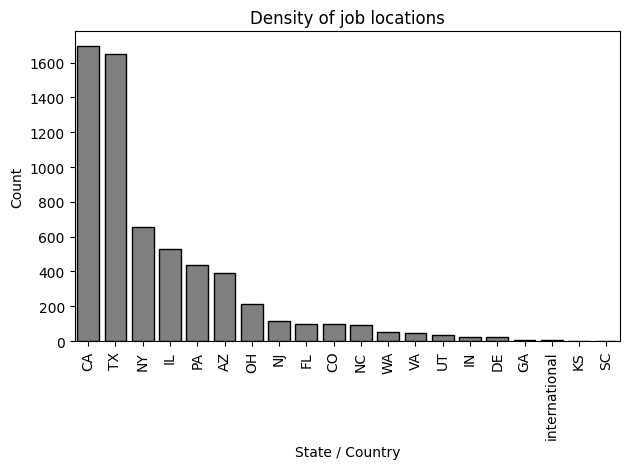

In [9]:
sns.countplot(
    data = df_ch0,
    x = 'state',
    color='grey',
    edgecolor = 'black',
    order=df_ch0['state'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('State / Country')
plt.ylabel('Count')
plt.title('Density of job locations')
plt.tight_layout()

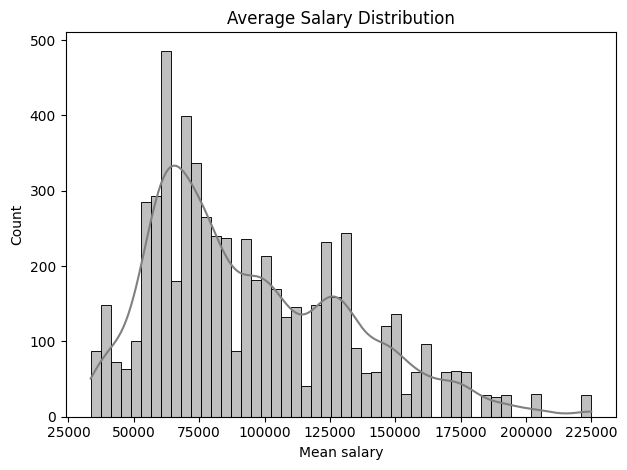

In [10]:
sns.histplot(
    data = df_ch0,
    x = 'sal_mean',
    color='grey',
    edgecolor = 'black',
    bins=50,
    kde=True,
)

plt.xlabel('Mean salary')
plt.ylabel('Count')
plt.title('Average Salary Distribution')
plt.tight_layout()

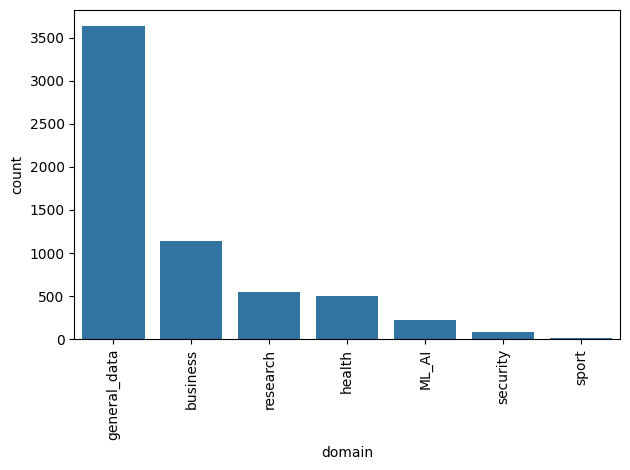

In [11]:
order = df_ch0['domain'].value_counts().index

sns.countplot(
    data = df_ch0,
    x = 'domain',
    order = order
)
plt.xticks(rotation = 90)
plt.tight_layout()

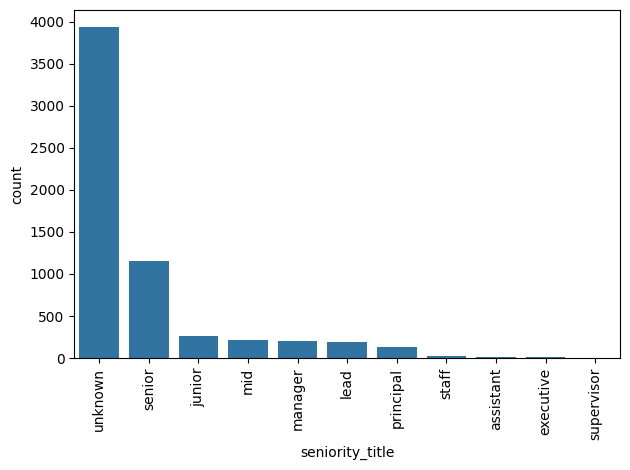

In [12]:
order = df_ch0['seniority_title'].value_counts().index

sns.countplot(
    data = df_ch0,
    x = 'seniority_title',
    order = order
)
plt.xticks(rotation = 90)
plt.tight_layout()

In [10]:
df_other = df_ch0[df_ch0["job_title_family"] == "other"][
    ["job_title_raw", "job_title_base", "job_title_norm"]
]
df_other

,job_title_raw,job_title_base,job_title_norm
3525,"Statistics Consultants for Thesis, Math Tutors...",statistics consultants math tutors math tutori...,
4674,"Sr. Computational Biologist, Immuno-Oncology",computational biologist immuno oncology,
4686,"Sr. Computational Biologist, Oncology Drug Dis...",computational biologist oncology drug discovery,
4699,Computational Biologist/Bioinformatics Position,computational biologist bioinformatics,
5348,Investigational Computational Biologist,investigational computational biologist,
